<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Delivery_Logistics_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Delivery Logistics Dataset


# About the dataset and Insights

Dataset is all about diamonds, specifically their characteristics and pricing. It's a fairly comprehensive collection, containing over 53,000 entries, with each entry describing a unique diamond across 10 different attributes. These attributes cover both quantitative measures like the diamond's carat weight, depth, table percentage, and its physical dimensions (x, y, z), as well as qualitative aspects like cut, color, and clarity. Crucially, it also includes the price of each diamond.

From a data quality perspective, we're in good shape! There are no missing values, which simplifies things. We did find about 146 duplicate entries, which were promptly removed to ensure our analysis is based on unique diamond records. This leaves us with a clean dataset ready for exploration.

Looking at individual features, the carat weight and price show interesting distributions, often skewed, meaning many diamonds are smaller and less expensive, with fewer very large or very costly ones. The cut quality is most frequently 'Ideal', while 'G' is the most common color, and 'SI1' is the most common clarity. These are important factors that jewelers and consumers consider.

When we examine the relationships between these attributes, some clear patterns emerge. Unsurprisingly, carat weight has a very strong positive correlation with price – bigger diamonds tend to be much more expensive. The physical dimensions (x, y, z) are also highly correlated with carat and price, which makes perfect sense as they directly relate to the diamond's size. We can also observe how cut, color, and clarity categories influence the price through visual comparisons, with higher quality grades generally associated with higher prices. These insights lay a solid foundation for understanding what drives diamond value.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d muhammadahmaddaar/diamonds-characteristics-and-pricing-analysis

# Unziping the downloaded file
!unzip diamonds-characteristics-and-pricing-analysis.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/muhammadahmaddaar/diamonds-characteristics-and-pricing-analysis
License(s): apache-2.0
  0% 0.00/582k [00:00<?, ?B/s]
100% 582k/582k [00:00<00:00, 1.00GB/s]
Archive:  diamonds-characteristics-and-pricing-analysis.zip
  inflating: diamonds.csv            


In [4]:
df = pd.read_csv('diamonds.csv')
df.head(11)

,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.23,Ideal,E,SI2,61.5,55.0,3.95,3.98,2.43,326
1,0.21,Premium,E,SI1,59.8,61.0,3.89,3.84,2.31,326
2,0.23,Good,E,VS1,56.9,65.0,4.05,4.07,2.31,327
3,0.29,Premium,I,VS2,62.4,58.0,4.20,4.23,2.63,334
4,0.31,Good,J,SI2,63.3,58.0,4.34,4.35,2.75,335
5,0.24,Very Good,J,VVS2,62.8,57.0,3.94,3.96,2.48,336
6,0.24,Very Good,I,VVS1,62.3,57.0,3.95,3.98,2.47,336
7,0.26,Very Good,H,SI1,61.9,55.0,4.07,4.11,2.53,337
8,0.22,Fair,E,VS2,65.1,61.0,3.87,3.78,2.49,337
9,0.23,Very Good,H,VS1,59.4,61.0,4.00,4.05,2.39,338


In [5]:
df.tail(11)

,carat,cut,color,clarity,depth,table,x,y,z,price
53929,0.71,Ideal,G,VS1,61.4,56.0,5.76,5.73,3.53,2756
53930,0.71,Premium,E,SI1,60.5,55.0,5.79,5.74,3.49,2756
53931,0.71,Premium,F,SI1,59.8,62.0,5.74,5.73,3.43,2756
53932,0.70,Very Good,E,VS2,60.5,59.0,5.71,5.76,3.47,2757
53933,0.70,Very Good,E,VS2,61.2,59.0,5.69,5.72,3.49,2757
53934,0.72,Premium,D,SI1,62.7,59.0,5.69,5.73,3.58,2757
53935,0.72,Ideal,D,SI1,60.8,57.0,5.75,5.76,3.50,2757
53936,0.72,Good,D,SI1,63.1,55.0,5.69,5.75,3.61,2757
53937,0.70,Very Good,D,SI1,62.8,60.0,5.66,5.68,3.56,2757
53938,0.86,Premium,H,SI2,61.0,58.0,6.15,6.12,3.74,2757


In [6]:
df.shape

(53940, 10)

In [7]:
df.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z',
       'price'],
      dtype='object')

In [8]:
df.dtypes

,0
carat,float64
cut,object
color,object
clarity,object
depth,float64
table,float64
x,float64
y,float64
z,float64
price,int64


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   x        53940 non-null  float64
 7   y        53940 non-null  float64
 8   z        53940 non-null  float64
 9   price    53940 non-null  int64  
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [10]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
carat,53940.0,NaN,NaN,NaN,0.79794,0.474011,0.2,0.4,0.7,1.04,5.01
cut,53940,5,Ideal,21551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
color,53940,7,G,11292,NaN,NaN,NaN,NaN,NaN,NaN,NaN
clarity,53940,8,SI1,13065,NaN,NaN,NaN,NaN,NaN,NaN,NaN
depth,53940.0,NaN,NaN,NaN,61.749405,1.432621,43.0,61.0,61.8,62.5,79.0
table,53940.0,NaN,NaN,NaN,57.457184,2.234491,43.0,56.0,57.0,59.0,95.0
x,53940.0,NaN,NaN,NaN,5.731157,1.121761,0.0,4.71,5.7,6.54,10.74
y,53940.0,NaN,NaN,NaN,5.734526,1.142135,0.0,4.72,5.71,6.54,58.9
z,53940.0,NaN,NaN,NaN,3.538734,0.705699,0.0,2.91,3.53,4.04,31.8
price,53940.0,NaN,NaN,NaN,3932.799722,3989.439738,326.0,950.0,2401.0,5324.25,18823.0


In [11]:
df.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
x,0
y,0
z,0
price,0


In [12]:
df.duplicated().sum()

np.int64(146)

In [13]:
df.drop_duplicates(inplace = True)

In [14]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

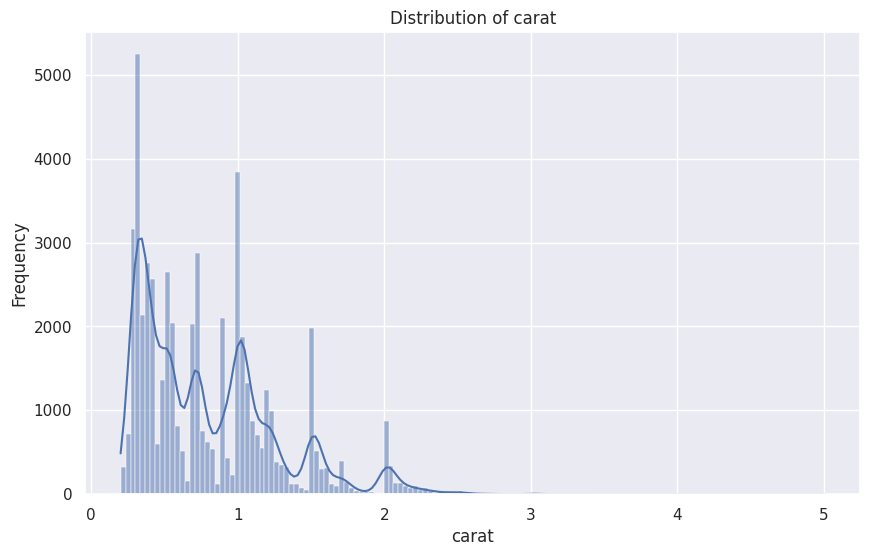

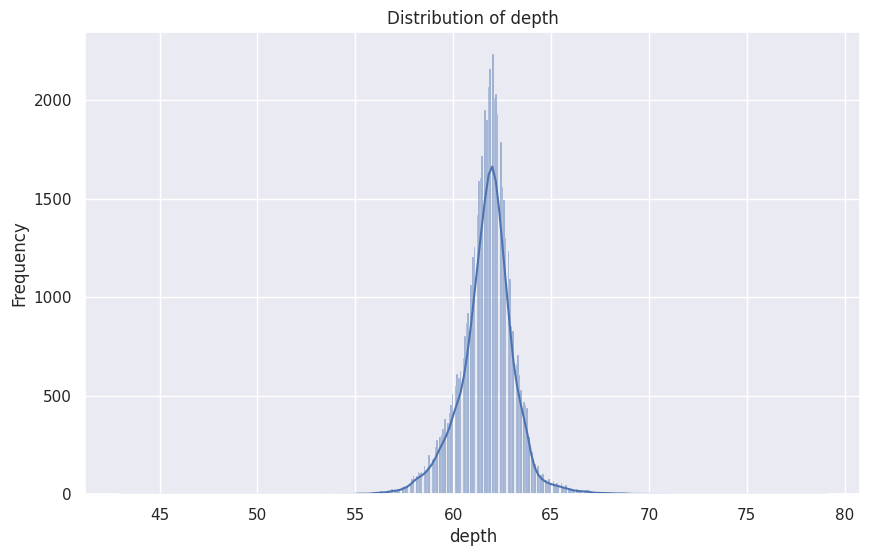

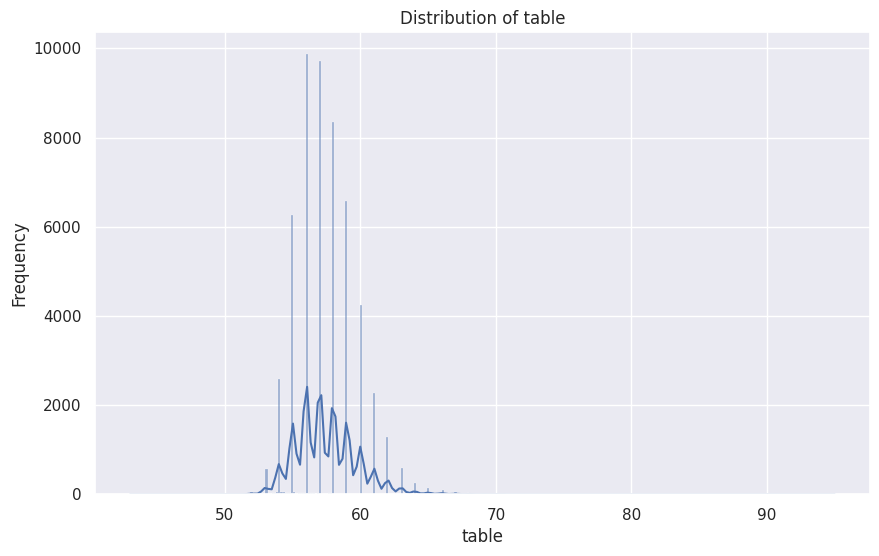

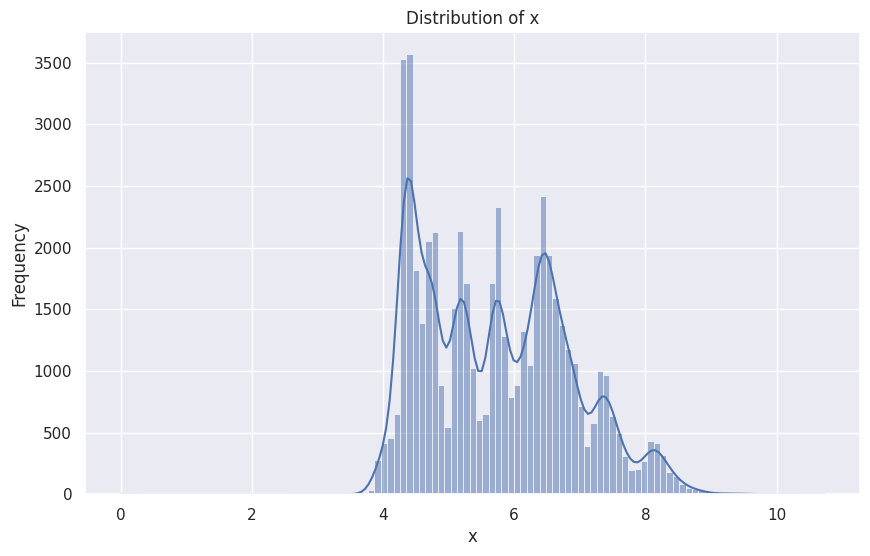

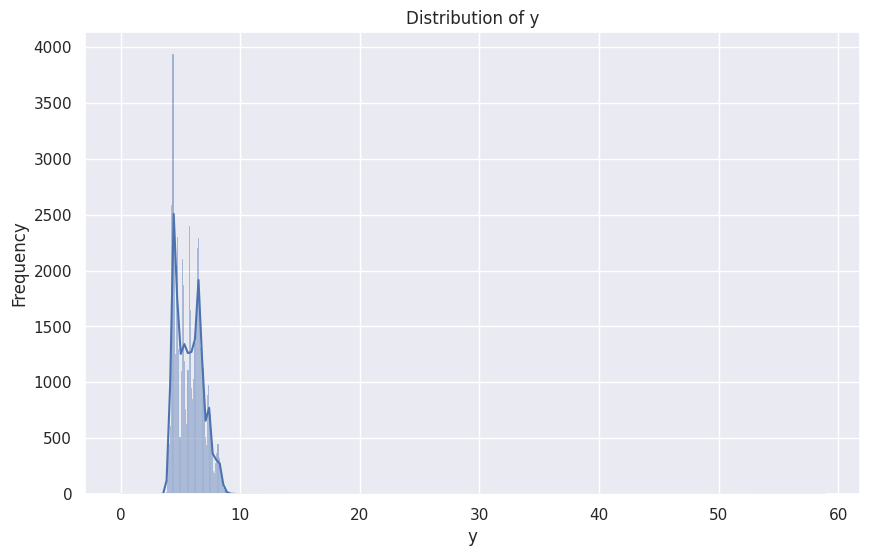

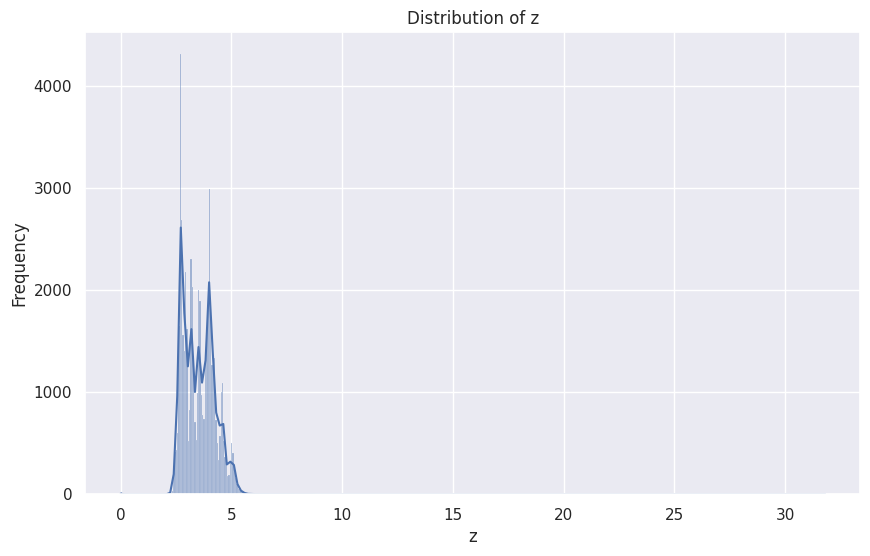

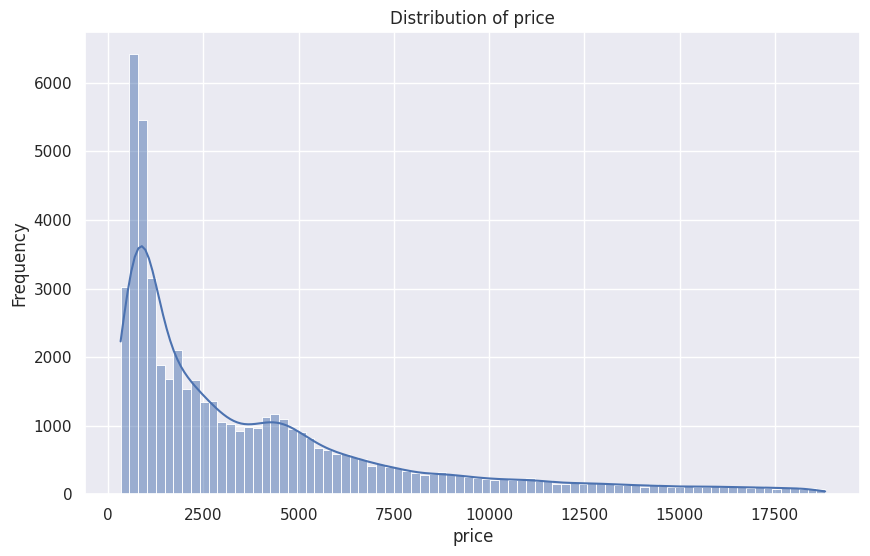

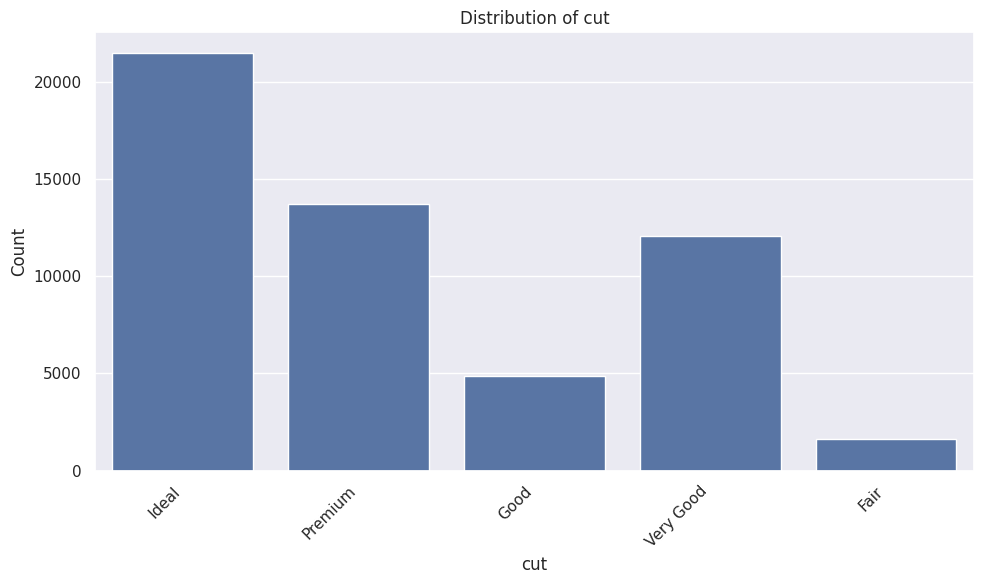

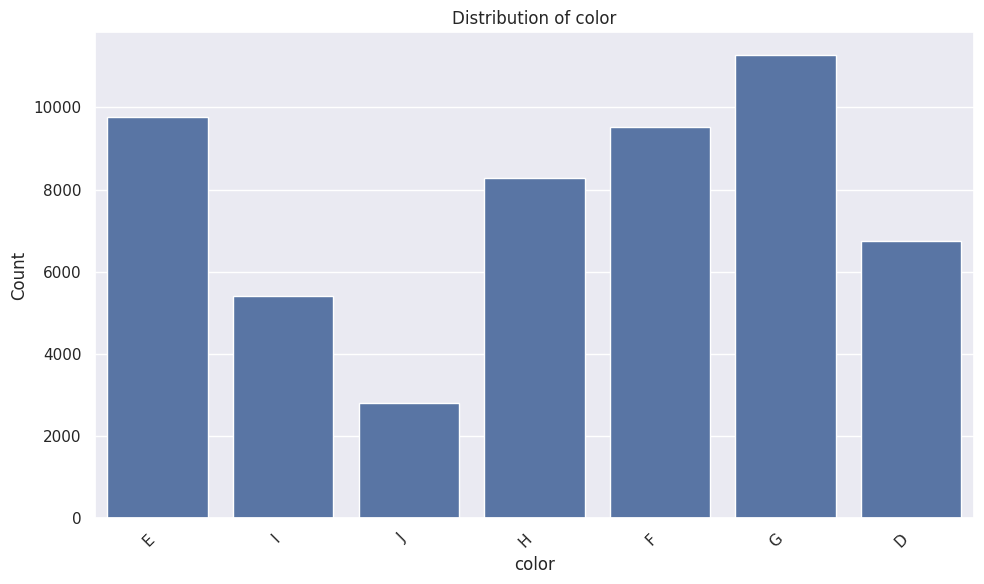

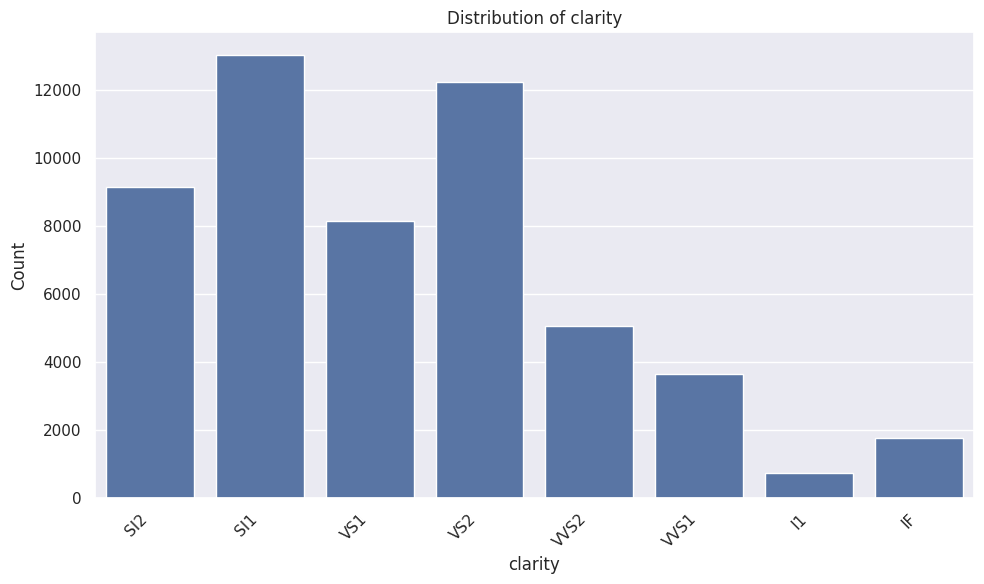

Value counts for cut:
cut
Ideal        21488
Premium      13748
Very Good    12069
Good          4891
Fair          1598
Name: count, dtype: int64

Value counts for color:
color
G    11262
E     9776
F     9520
H     8272
D     6755
I     5407
J     2802
Name: count, dtype: int64

Value counts for clarity:
clarity
SI1     13032
VS2     12229
SI2      9150
VS1      8156
VVS2     5056
VVS1     3647
IF       1784
I1        740
Name: count, dtype: int64



In [15]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterating through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

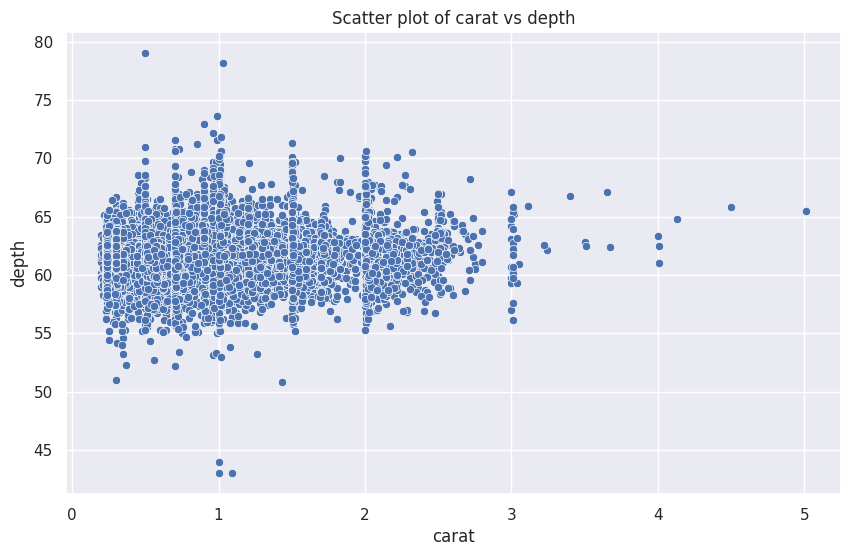

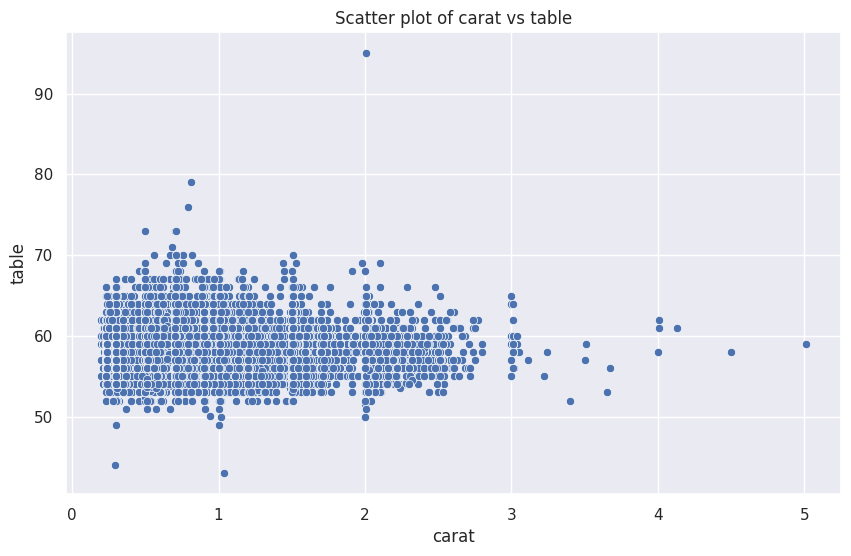

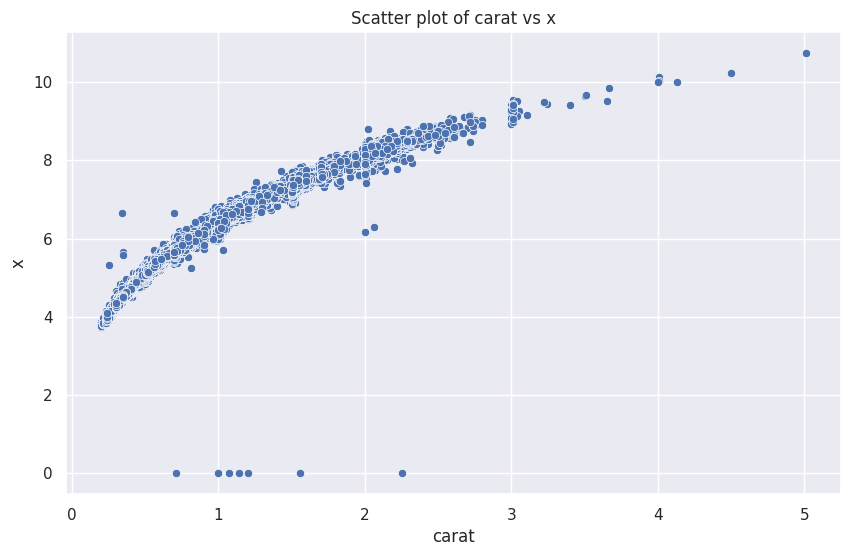

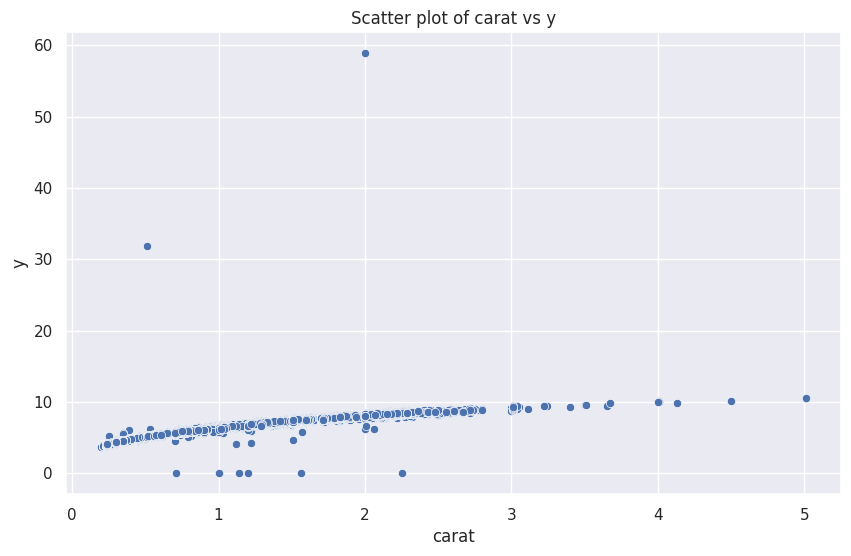

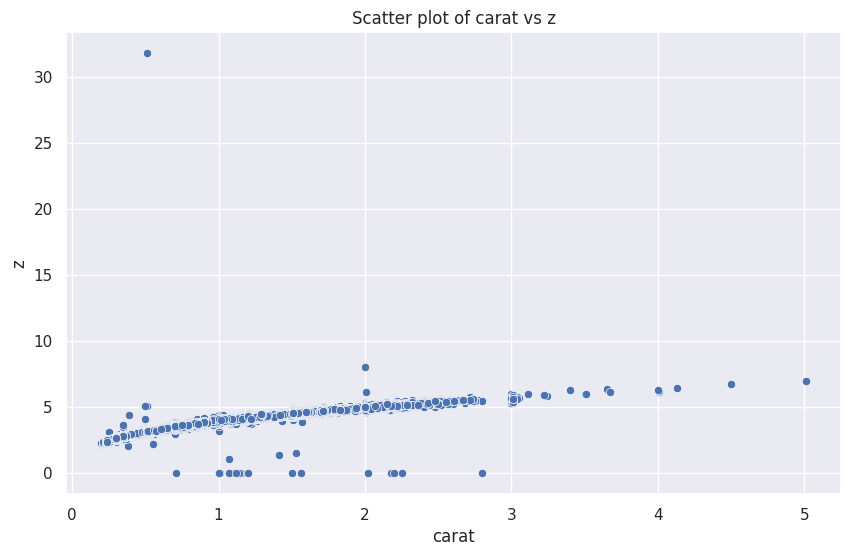

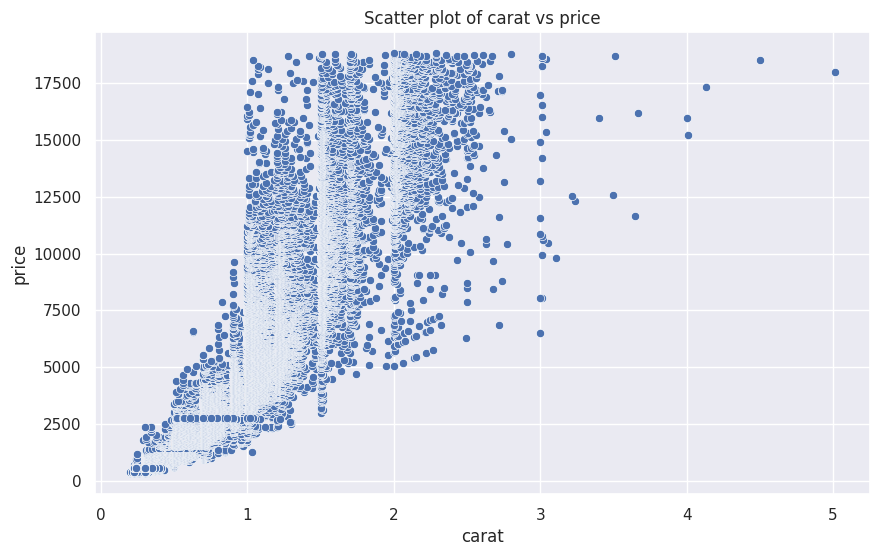

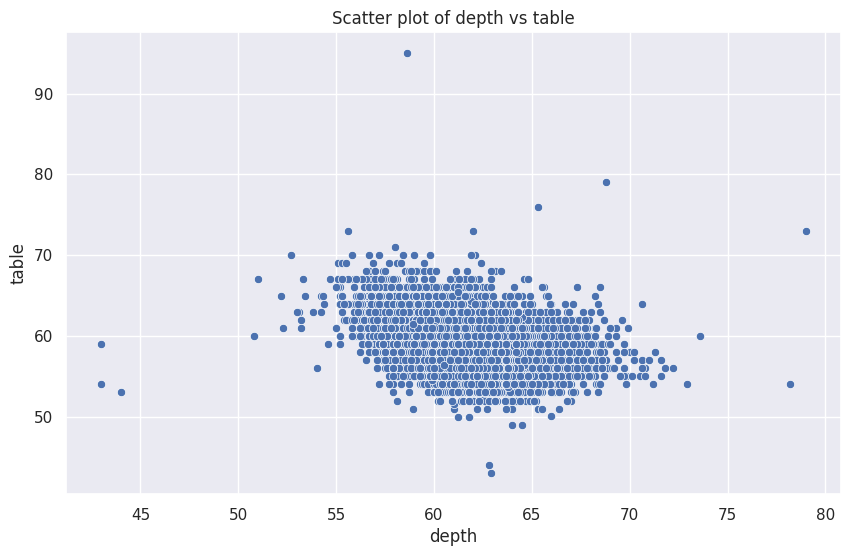

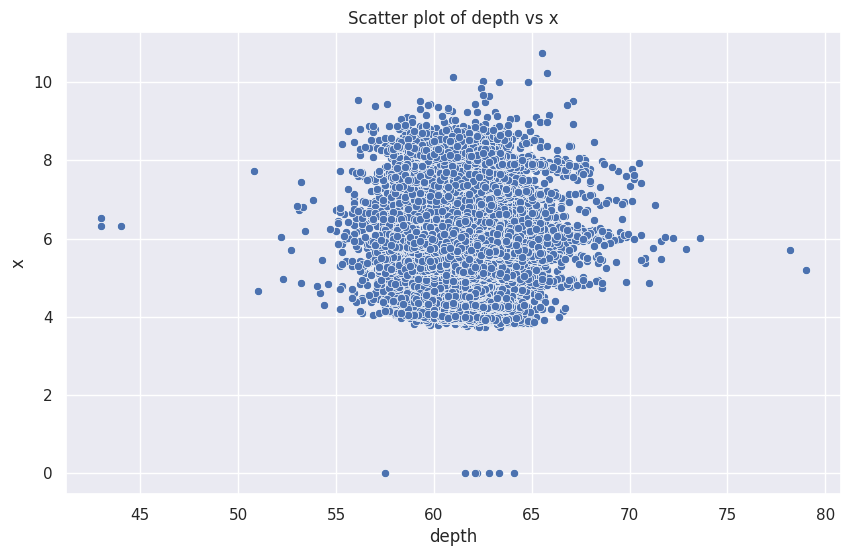

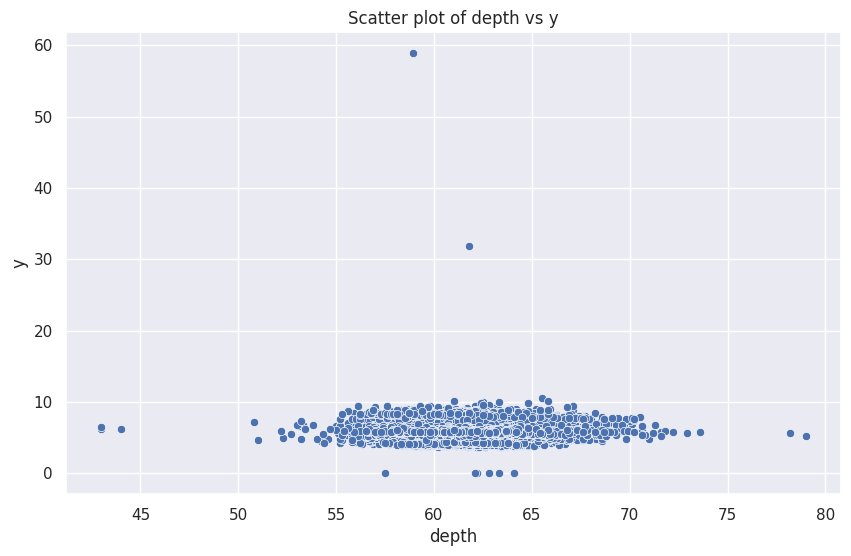

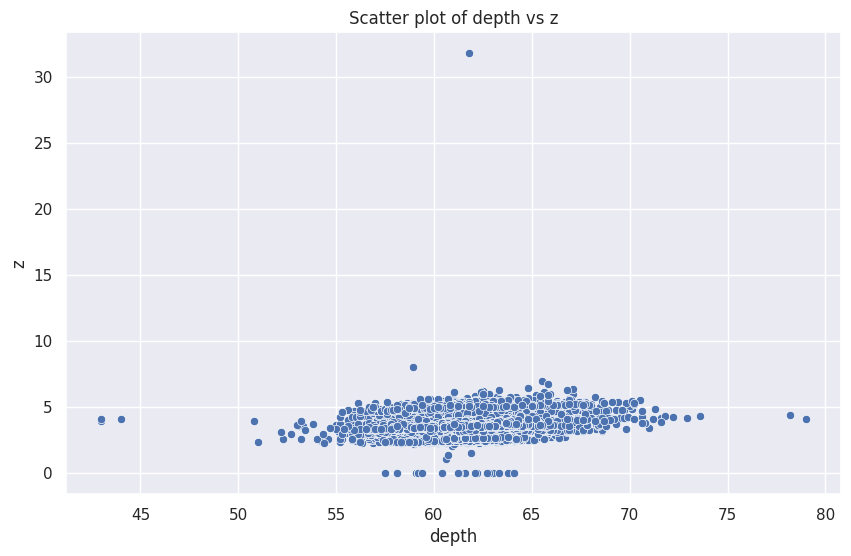

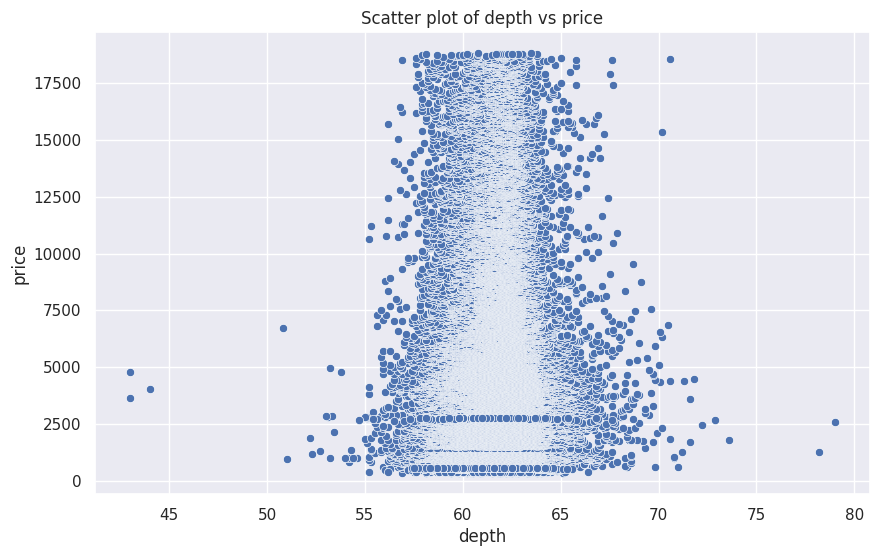

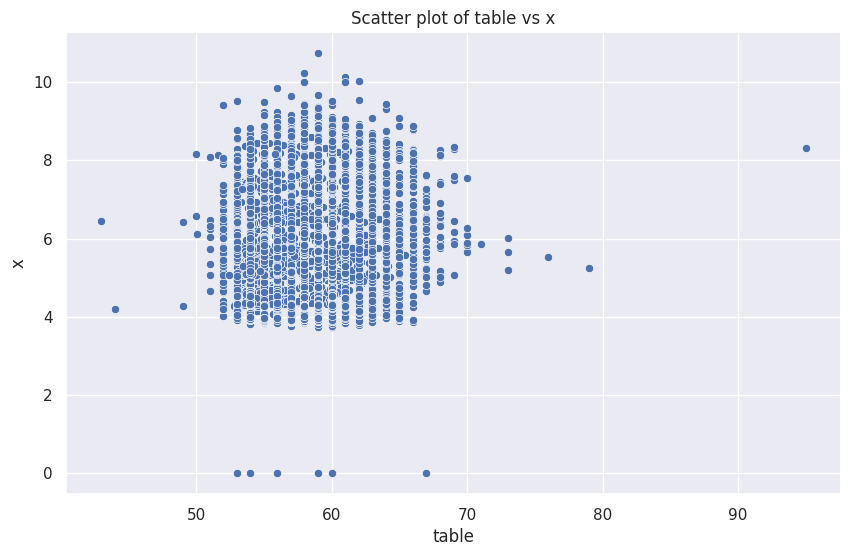

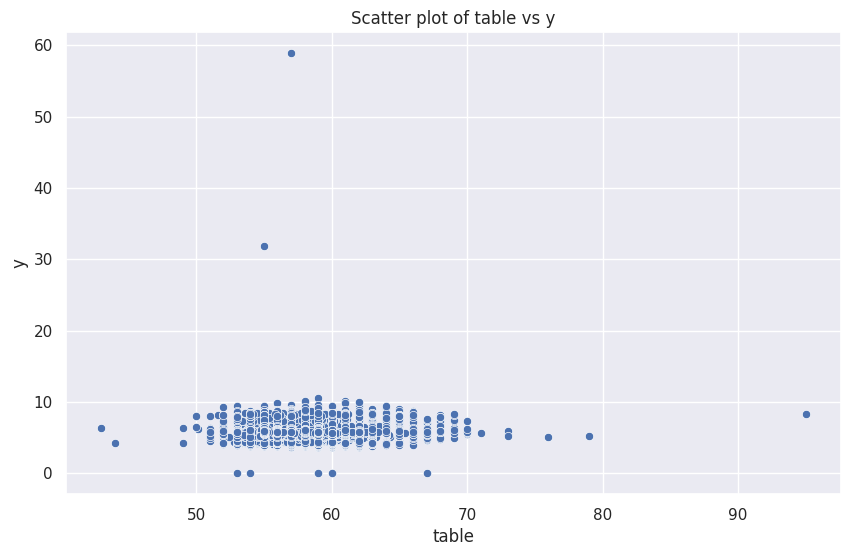

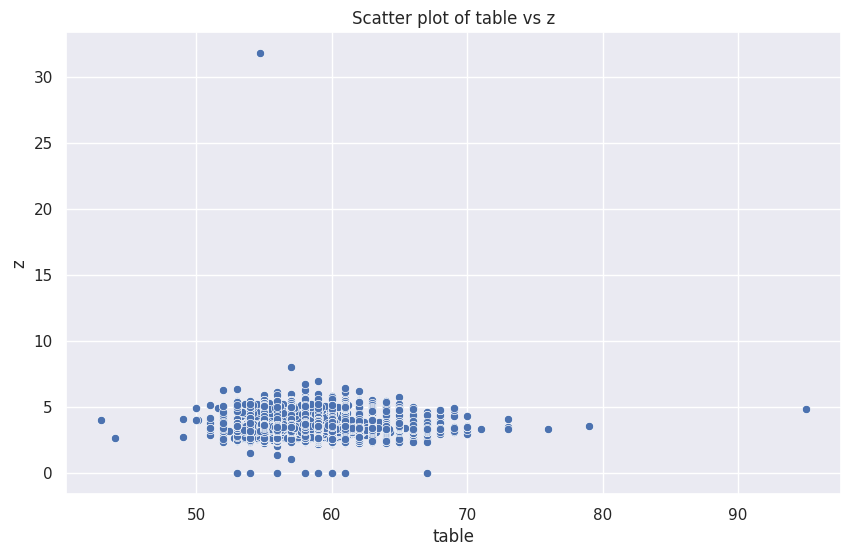

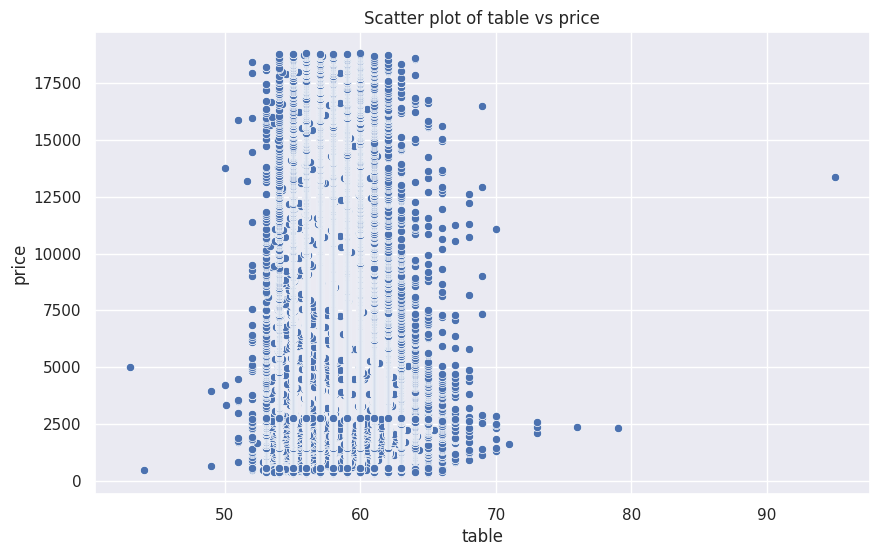

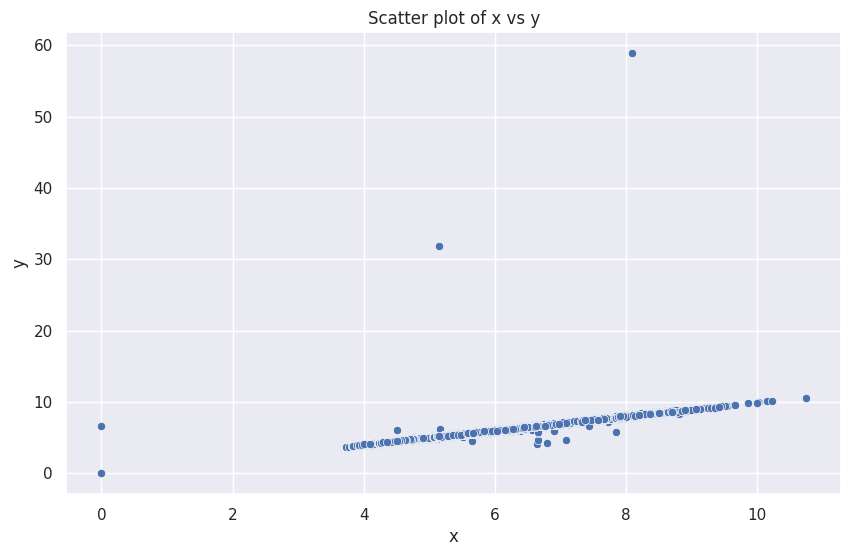

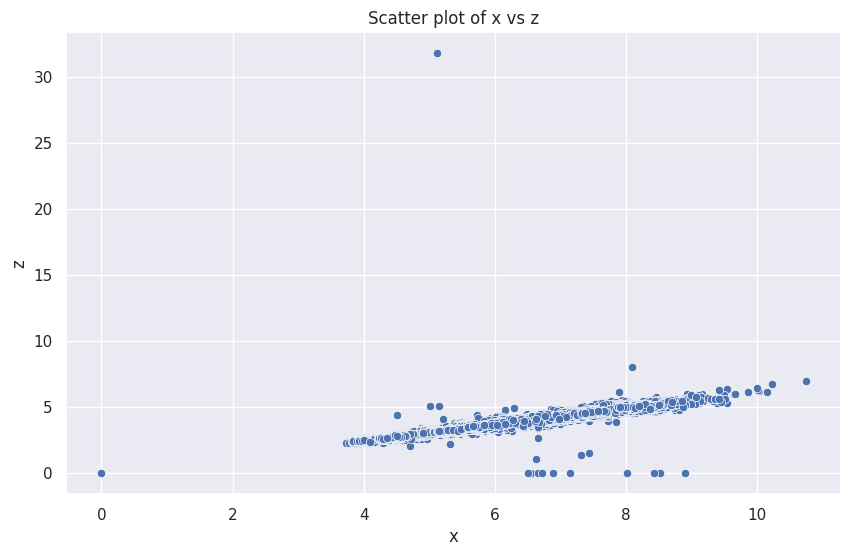

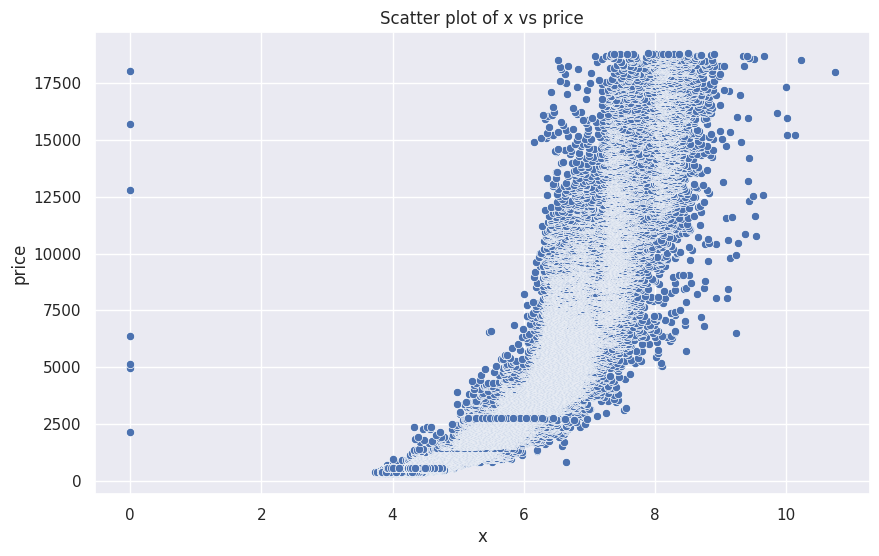

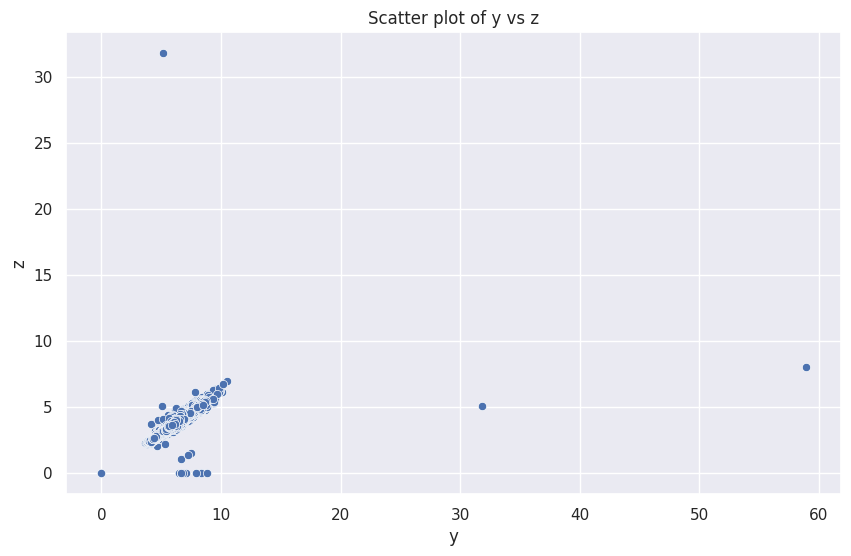

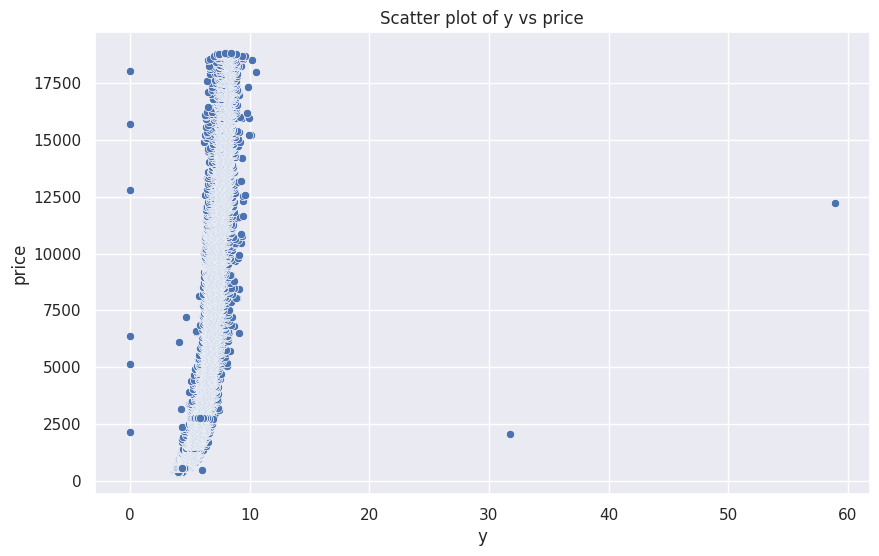

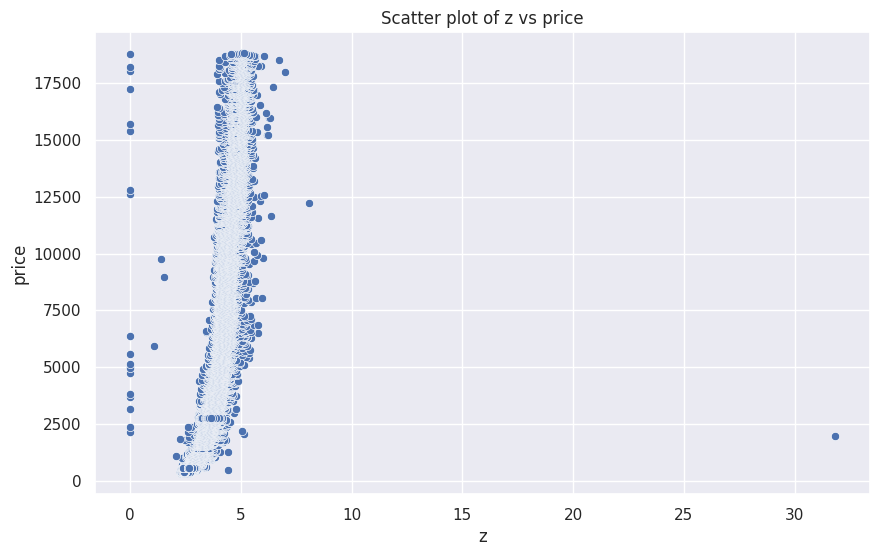

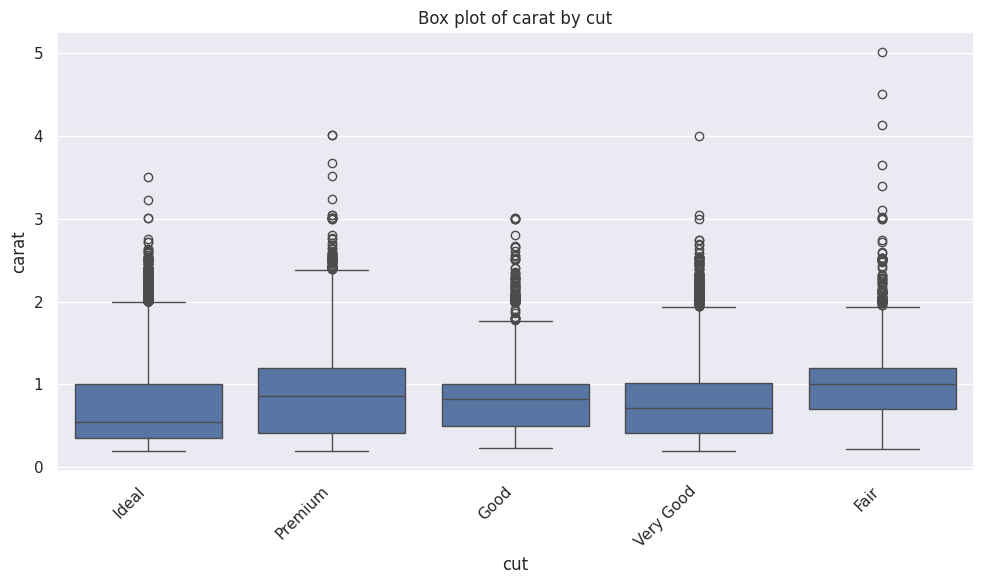

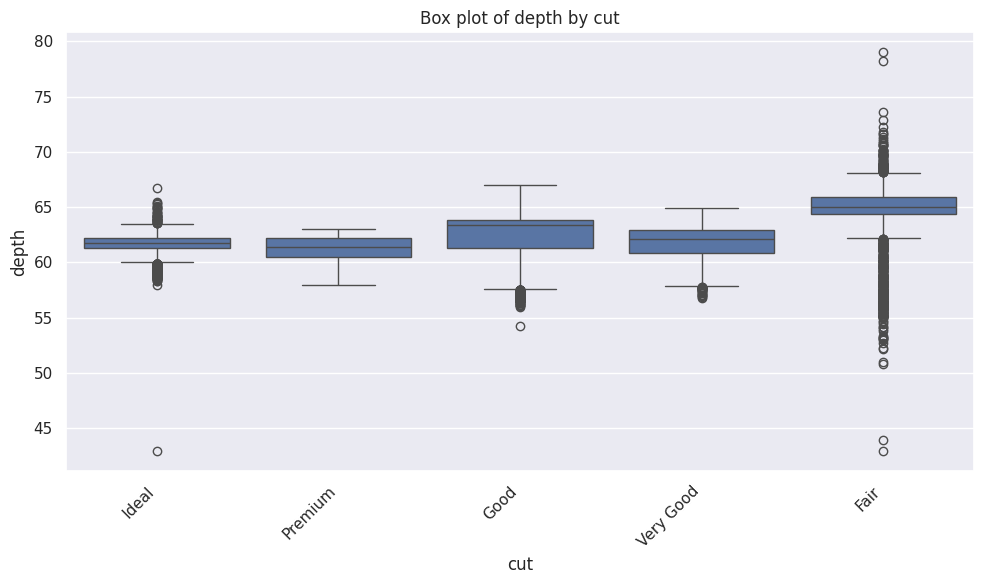

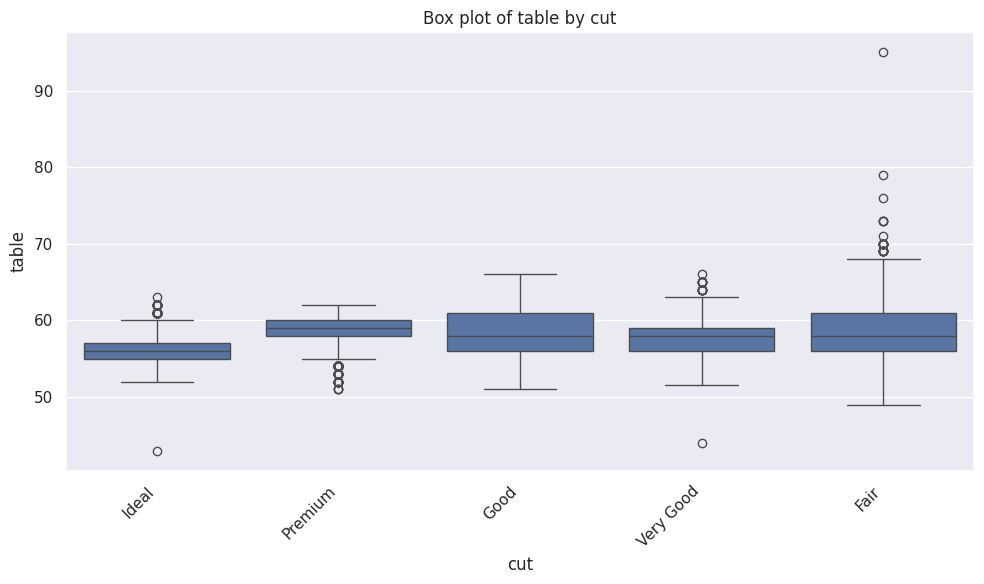

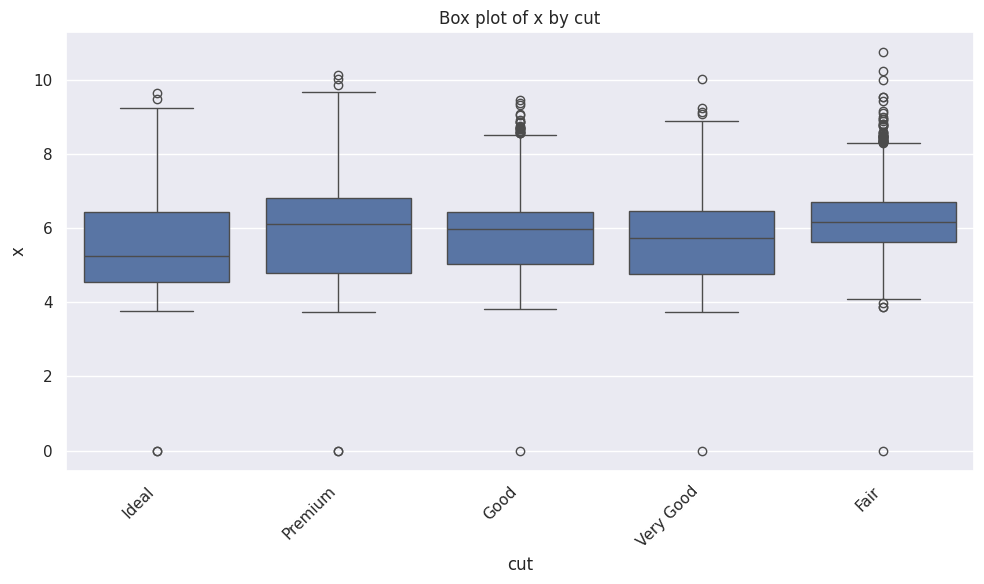

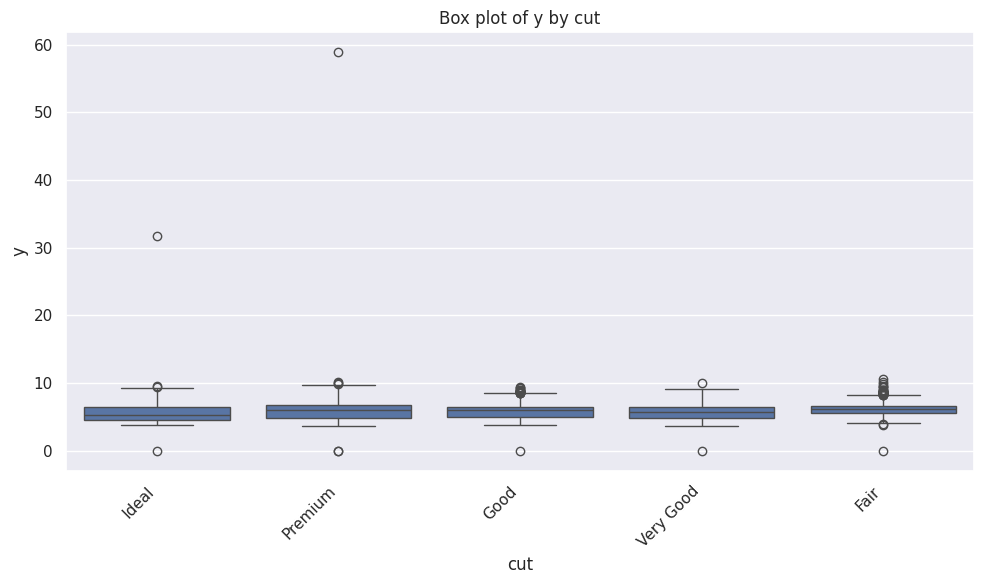

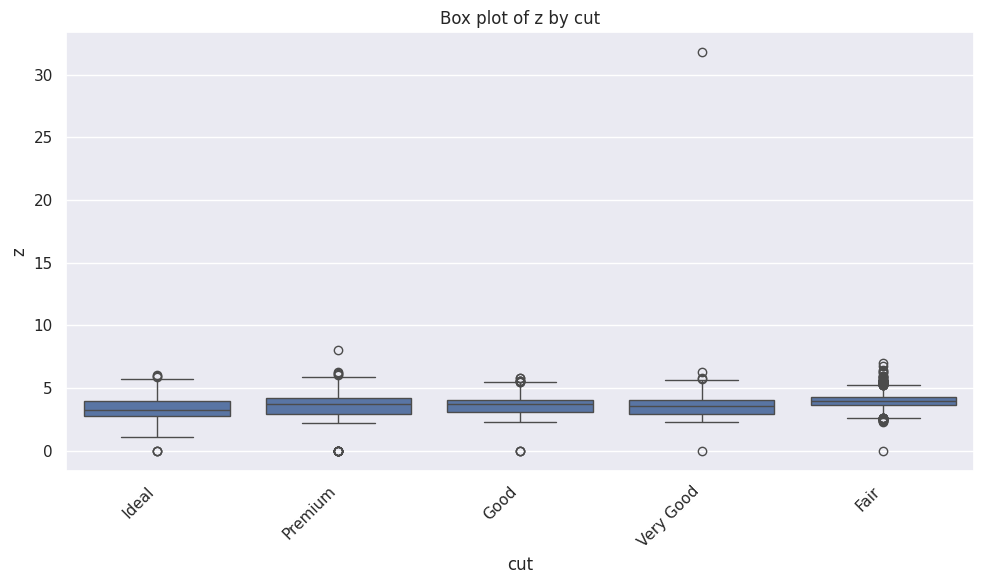

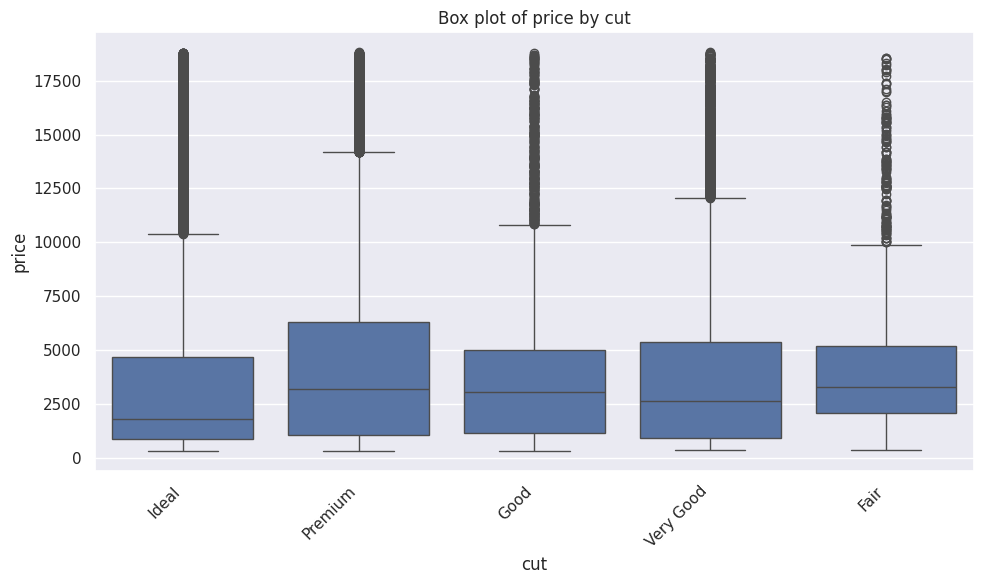

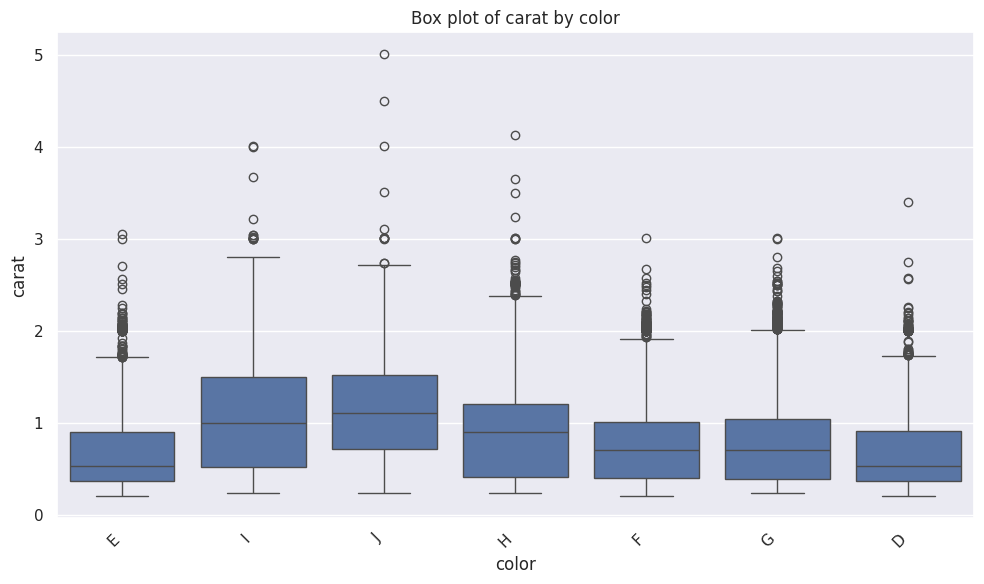

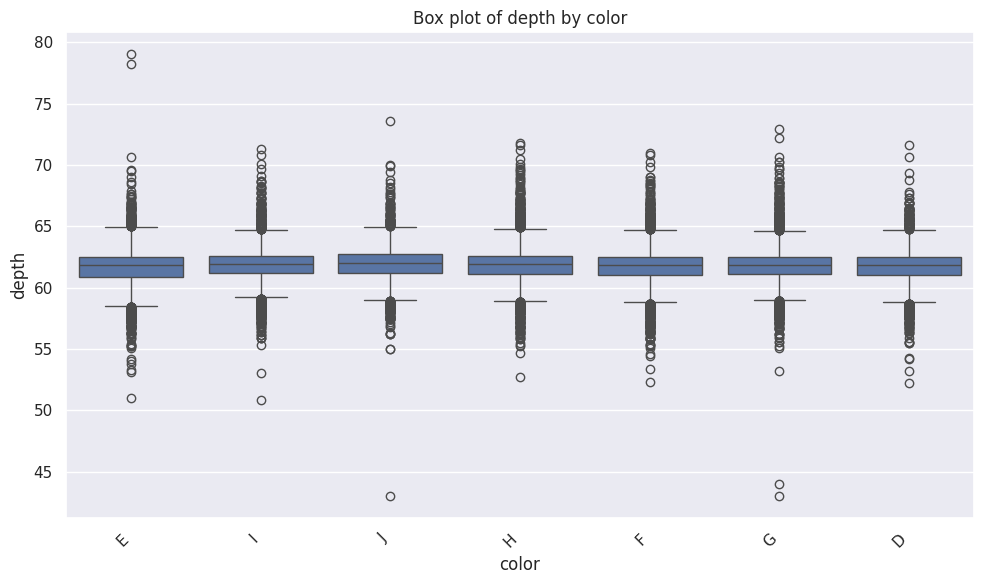

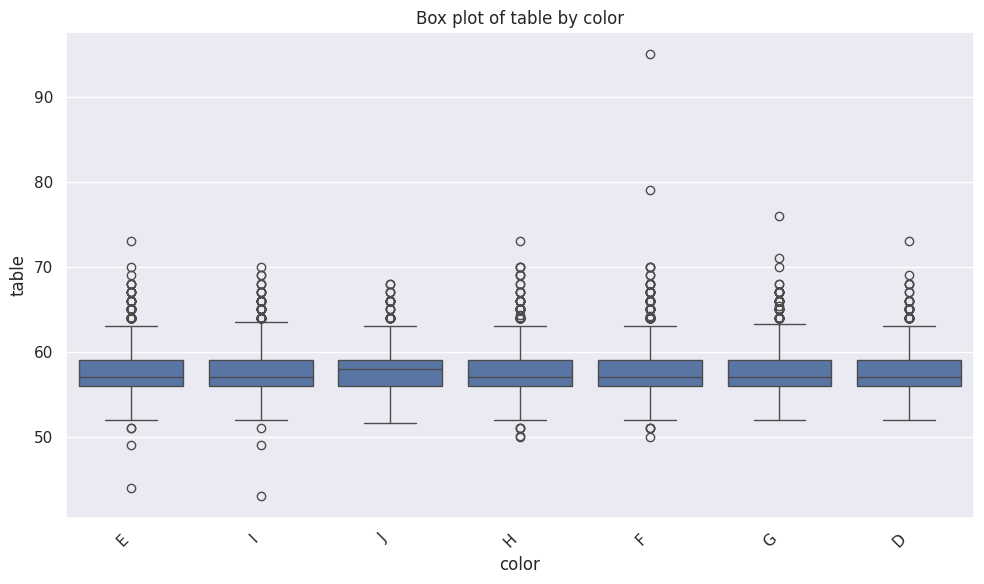

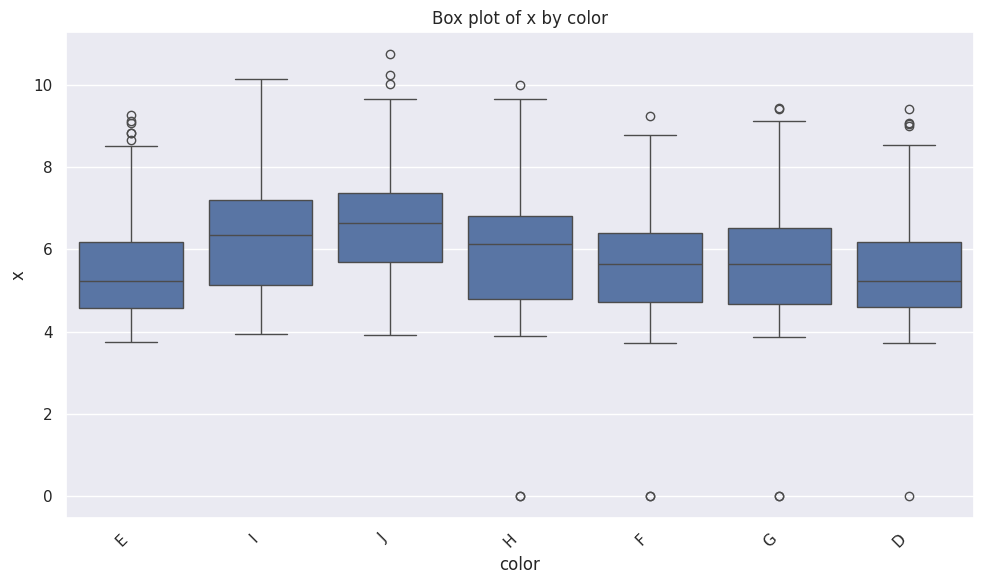

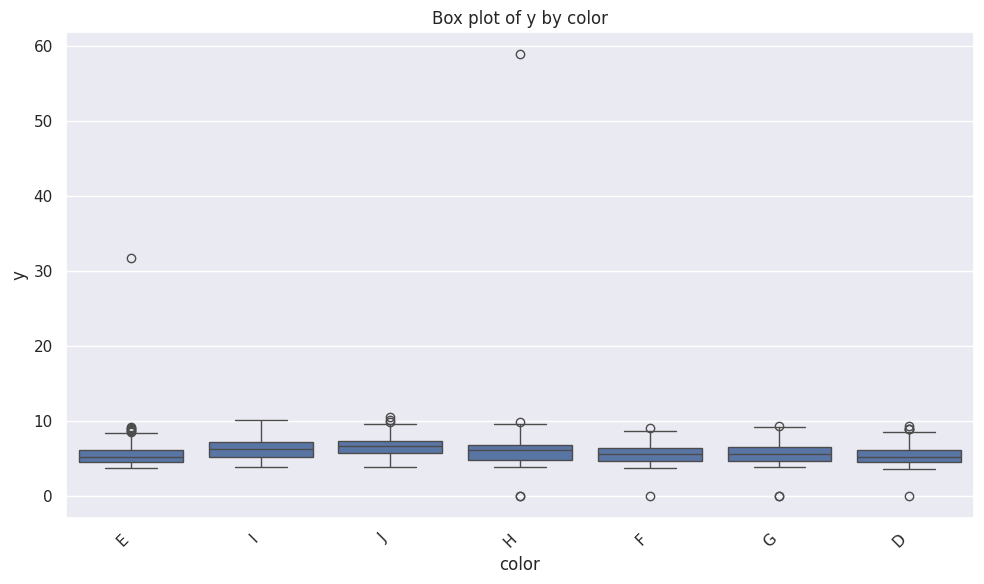

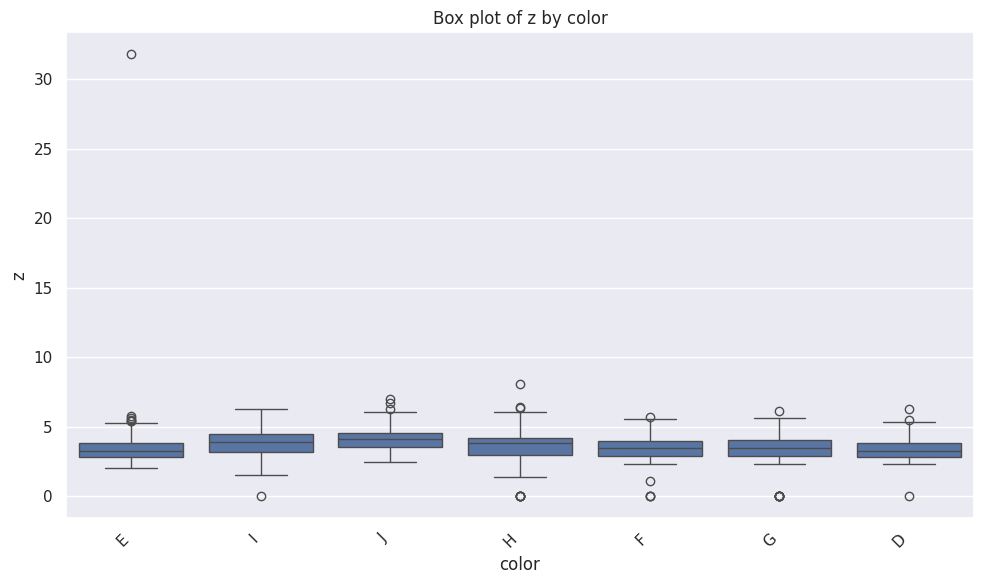

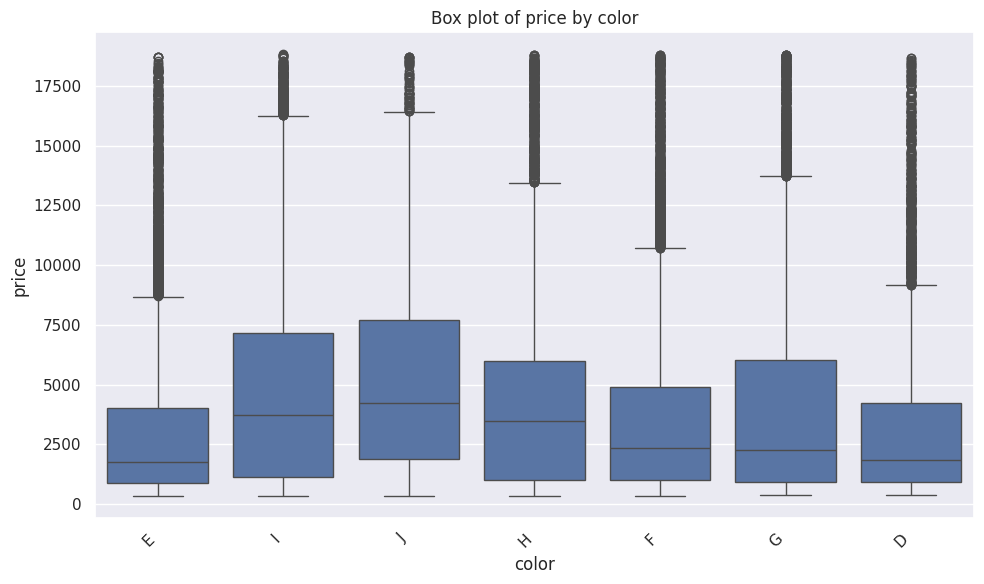

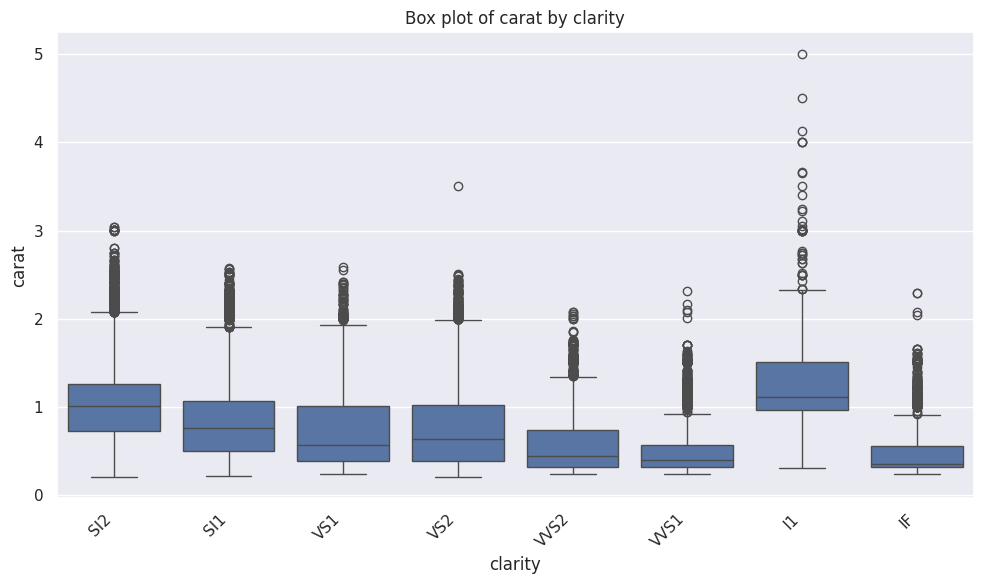

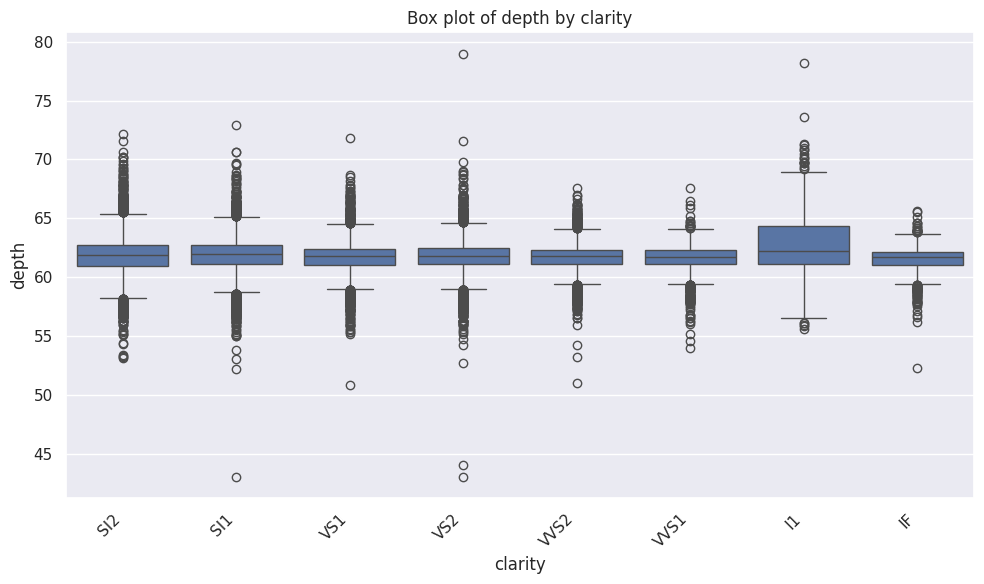

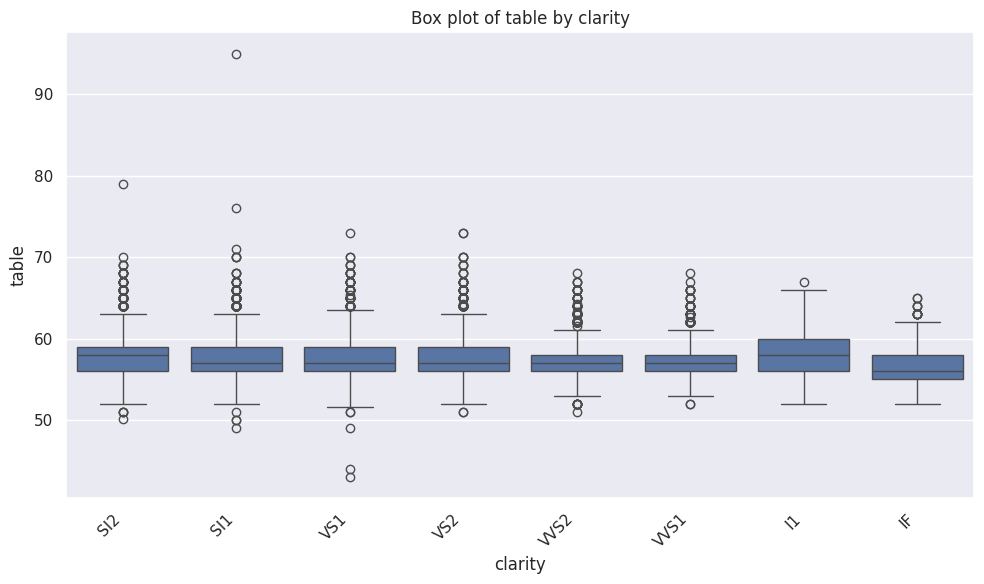

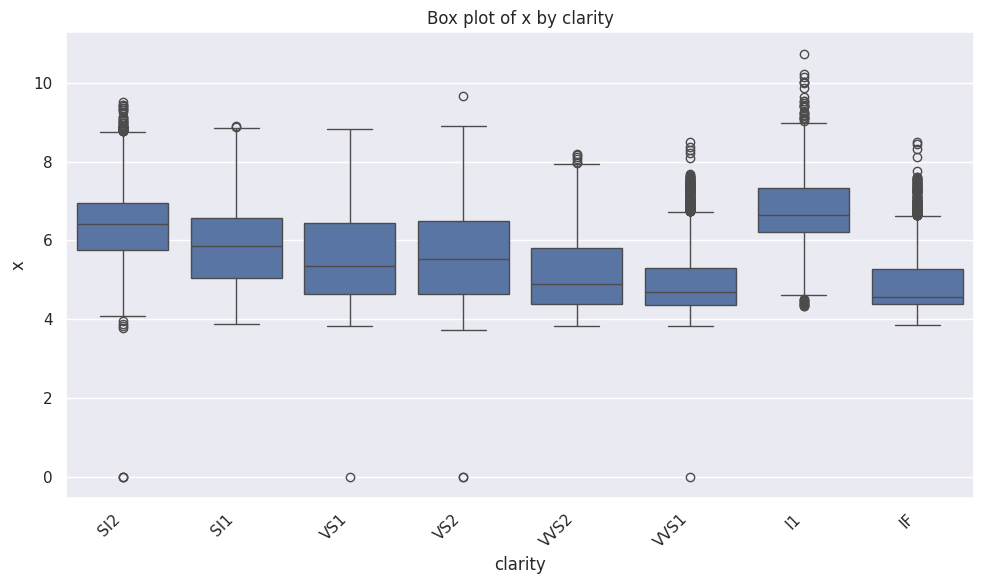

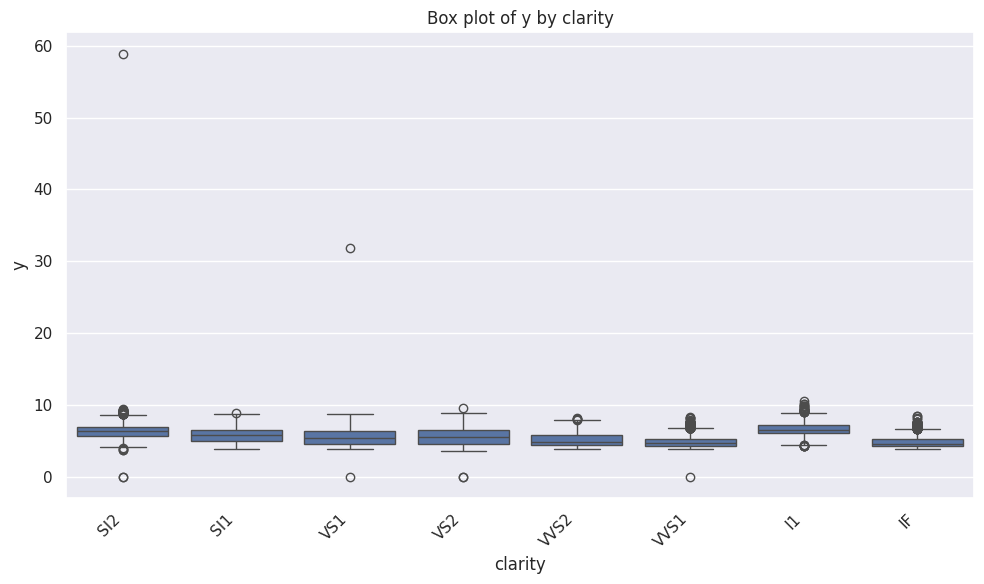

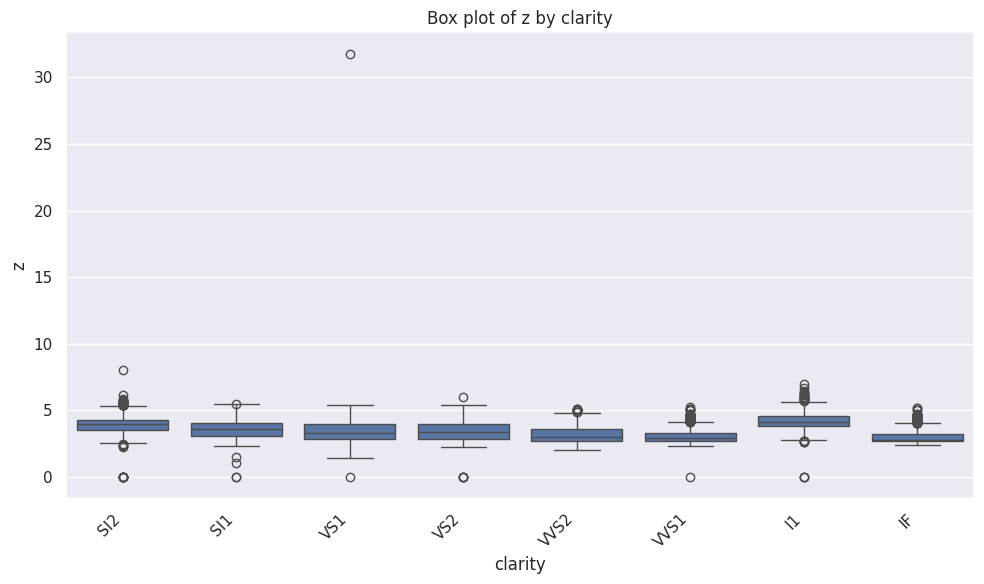

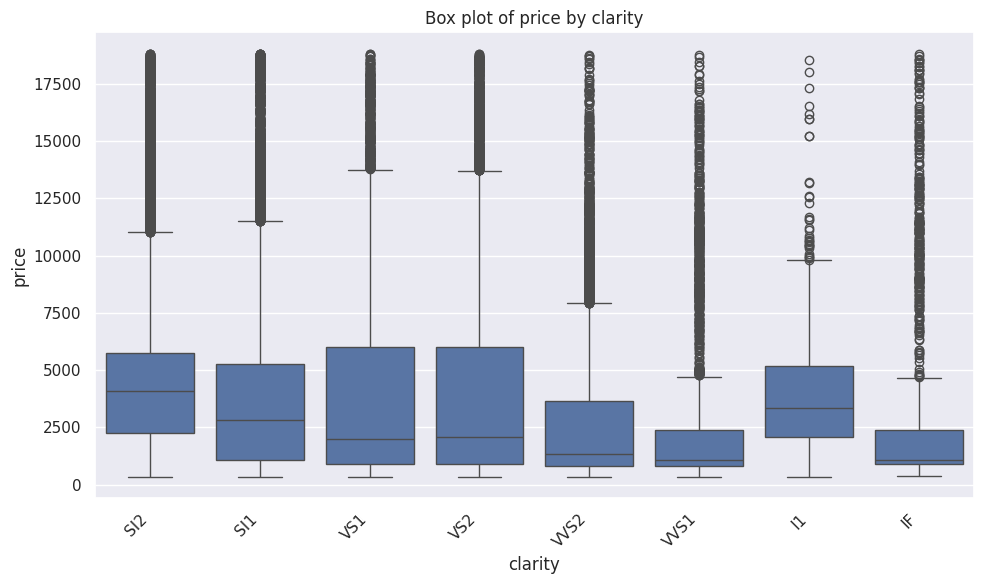

In [16]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

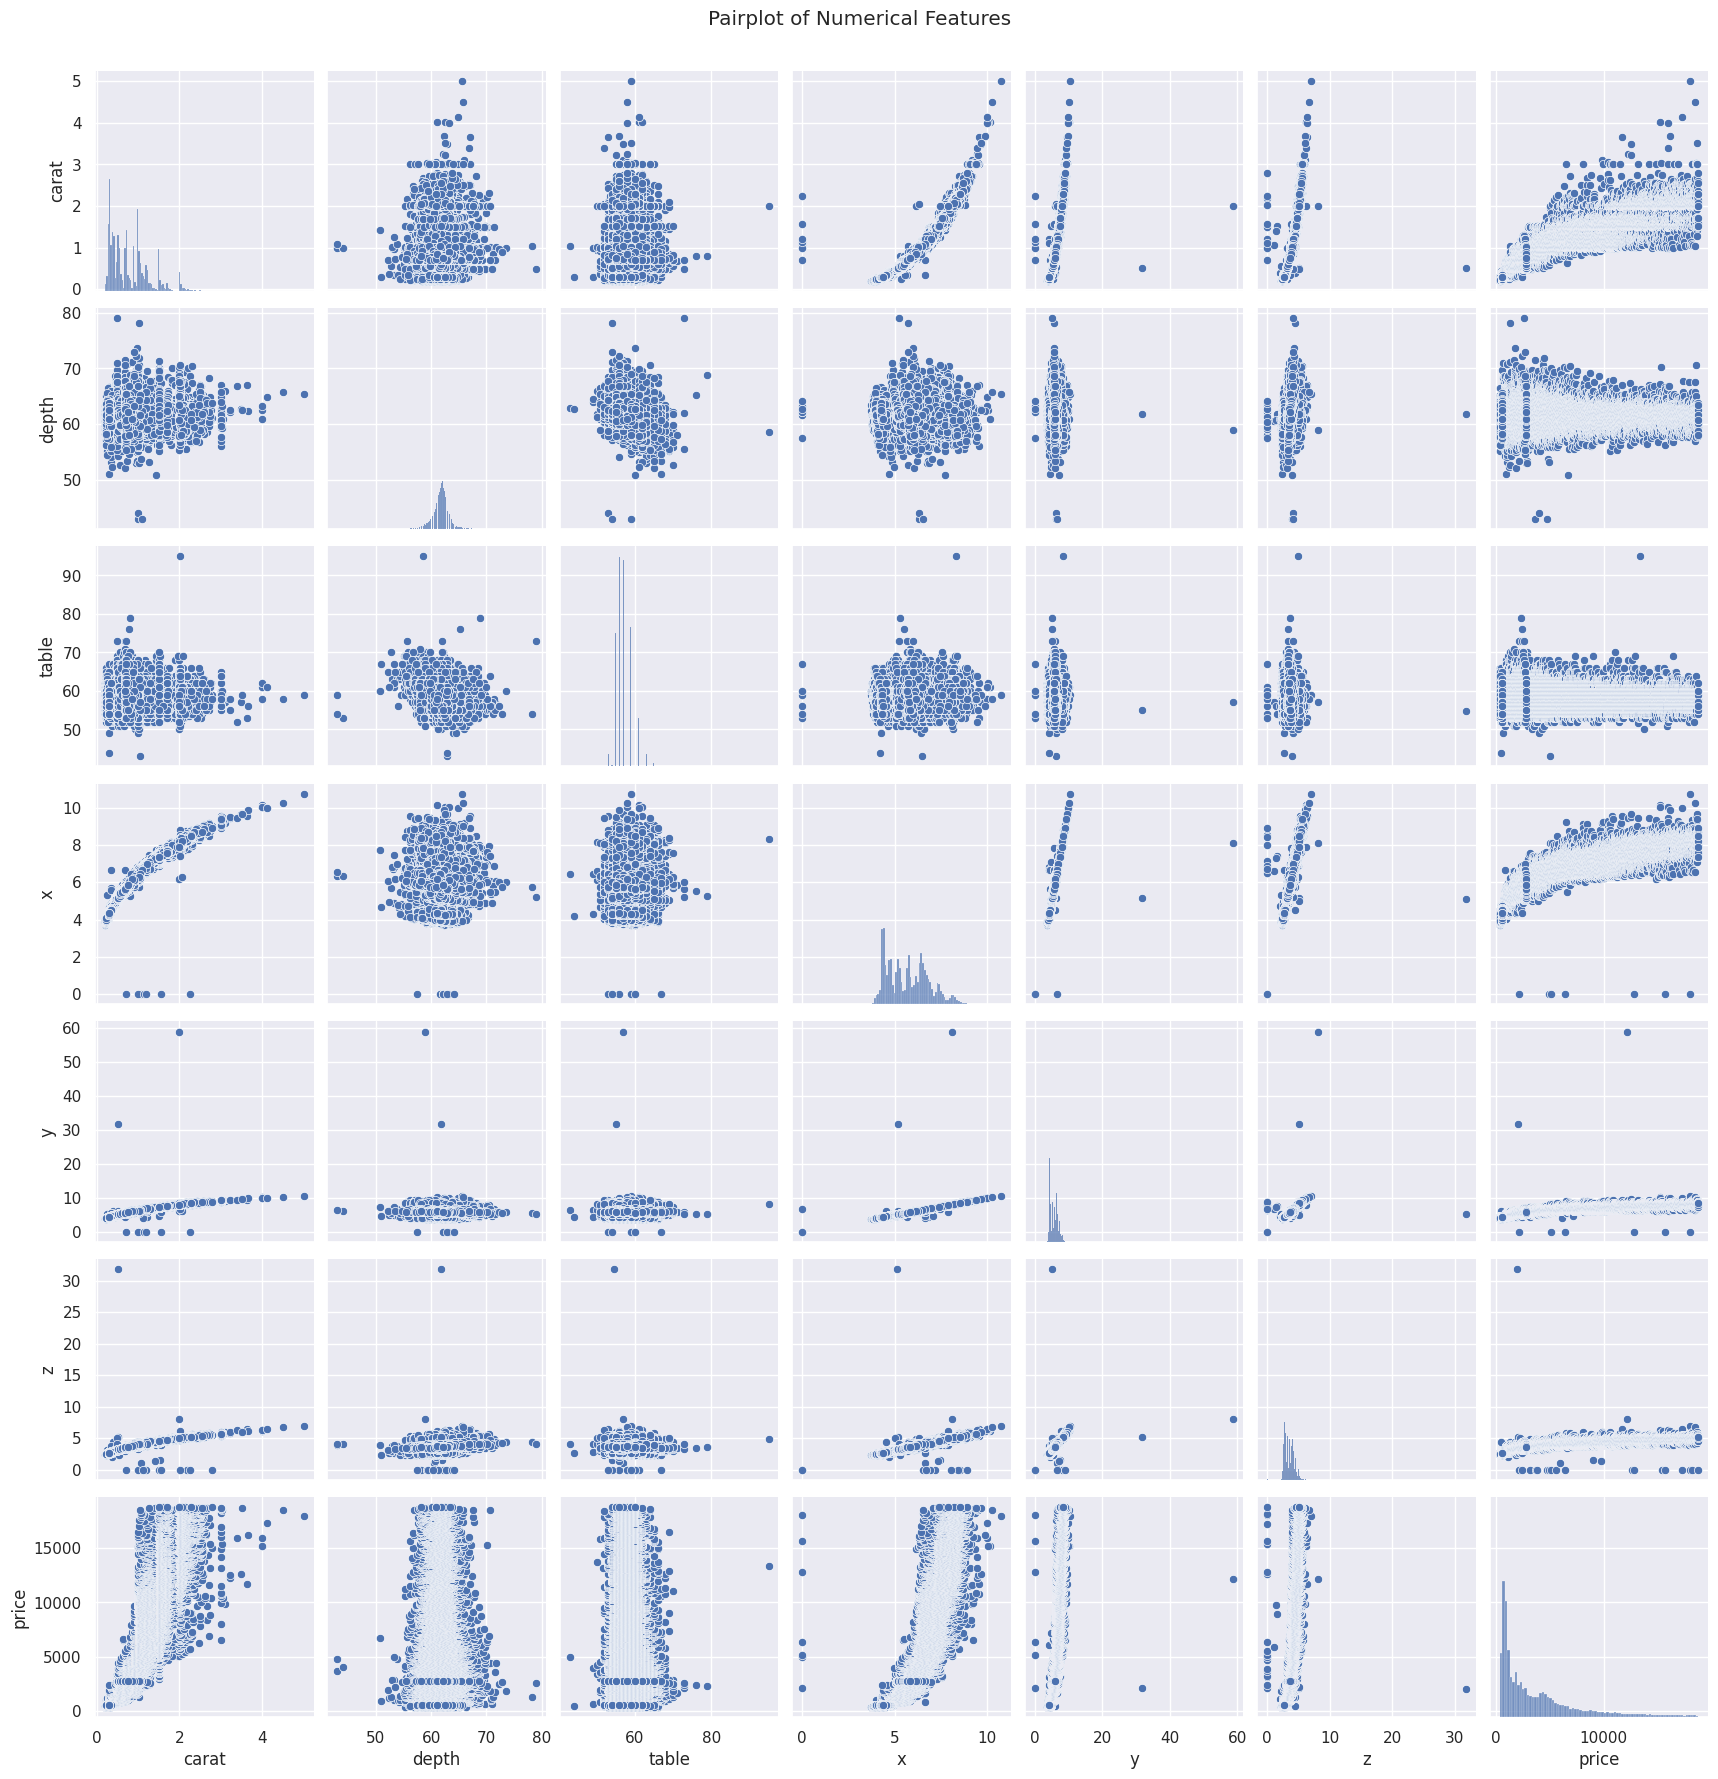

In [17]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

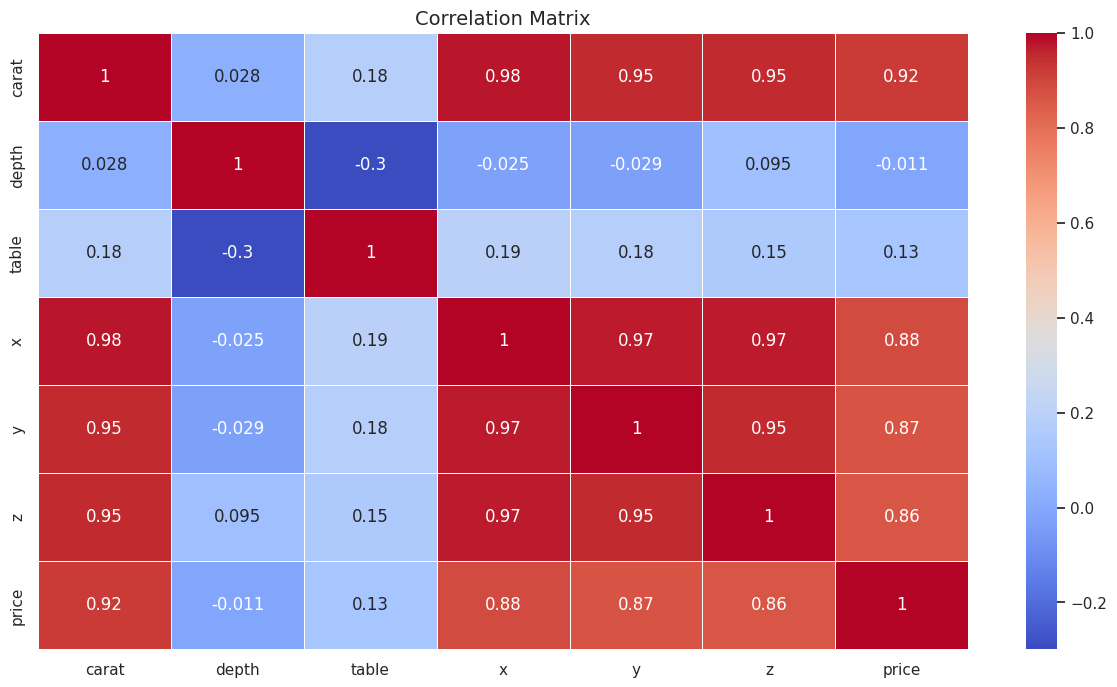

In [18]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank You